# Assignment 3 - Hydraulic Cross Section

Group 30

Gabriel Leite Savegnago - 1716255

Robin Chung - 1647806

Filip Atanasovski-1833103



## Introduction

In this assignment, we are going to construct a convolutional neural network that computes the Hydraulic throughput. Firstly, the theory and concept that is utilized in our neural network will be explained. For instance, the scaling function we have decided to use, the symmetries of the problem we identified and how all the symmetries of the problem can be hardwired in a network. After understanding the knowledge, we will jump into the actual implementation of the theories and concepts we are going to explain later onto our neural network trainings. Compare to the last two assignment, this time we are going to use convoltional neurual network as our deep learning as the given input is a 40x40 image.

Before we start, use your own method to import the data before running any line of code later.


## Part 1 : Theoretical Aspect

### Physical Dimensions and Symmetry of the Problem

Given that the map given to us is made out of either 1 or 0 indicating if the porous material can let in water through that pixel or not respectivelly. It is said in the assigment that we can interpret those values to have the unit of $m^2$ and the thoroughput to have the unit of $m^4$. Given that the values of the input are either 0 or 1 it is useless to square them or square root them, so to make this neural network homogeneus we have to it by changing the output during training the model. We do that by taking the square root of every value in the training values of the hydraulic throughput, so doing so the output and input would have homogeneus values that being $m^2$.


We have identified 8 symmetries that preserve the needed property. As the hydraulic throughput can be estimated using the pixel map of the porous material, as the following transformations dont essentially change that map, but just flip it various ways, with the structure being preserved, that would then mean that the estimation of the hydrulic thoroughput of all of these symmetires should all be the same as we do not change any of the variables that matter. Those symmetires are demonstrated in the following images, as the matrix given to us is 40x40 and thus represented by a square.

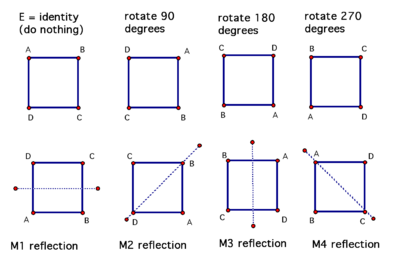
<figcaption align = "center"> Figure 1[1]</figcaption>


## Symmetries

In the previous section, multiple symmetries were mentioned. From the mentioned symmetries, all of them have something in common: applying such symmetries does not modify the shape or expected hydraulic throughput of the data. With symmetries one must; augment, disambiguate or "hardwire" the symmetry [2]. Handling symmetries is important since, when applied correctly, it boosts the model's performance [5]. Data augmentation is increasing of the dataset by applying symmetries or adding symmetric cases, such that the model is robust under many conditions. Conditions that can be possible, however, are not represented in the data. Data disambiguation however is restricting the dataset to a specific condition [2]. Besides data augmentation, the model can also be developed in such a way that it respects the symmetry. Developing an NN that must respect symmetries is, "hardwiring" a symmetry in a NN [2].

An important invariance is rotational invariance, because when the material is rotated, the flow through the material is unchanged. Another important invariance is reflection invariance, where when the porous material is mirrored then the direction of the flow is altered however the expected hydraulic throughput is unchanged. Transposition is also an invariance since when the porous material is flipped along the diagonal, then the flow inside flips its directions, however the expected hydraulic throughput is unchanged.

###Mirroring
As listed in the image from the previous section, there are two mirroring symmetries. Similarly to rotation, each mirroring symmetries can be applied with two methods, horizontal mirroring or vertical mirroring. The implementation of the vertical mirroring can be implemented through $matrix.flip()$. For an input with a 4x4 matrix, where each column is indexed by (0,1,2,3), the method includes setting 0 as 3 and 1 as 2, hence (3, 2, 1, 0). The implementation of horizontal mirroring is similar.

###Transposition
The symmetries noted as M2 and M4 are implemented through transposing. When transposing a matrix, the rows become columns. An example is row (0,1,2,3) which when transposed becomes a column with (0,1,2,3), where 0 is in the first row and 3 is in the last row. For symmetry M2, the matrix is also transposed however, it is first mirrored vertically and then transposed.

###Rotation
A group of symmetries listed above is rotation. Where the image is rotated by 0, 90, 180 or 270 degrees to a specific orientation. In python, this can be implemented with various utilization of horizontal, vertical mirroring and transposition. This method can be utilized twice or three times to rotate by 90, 180 or 270 degrees.

###Data Augmentation
Data augmentation is a very important technique that when applied justly can vastly improve the performance of a model. A possible technique that can be applied is, applying the symmetry on each image in the data set. The symmetries that can be applied are the rotations and mirroring through each orientation. Applying the symmetries to the inputs in such manner is possible since the expected value remains the same. An input x would hence generate 7 additional inputs, which the model can utilize to further depict features. By using this technique, the set of data would thus vastly increase.

###Disambiguation
Instead of increasing the data set, disambiguation tends to limit the data set. A strategy for disambiguation that can be utilized is setting the 40x40 images to four 10x10 quadrants, where combining the four quadrants forms the same 40x40 image. The pixels in the images are binary within the matrix, hence either 0 or 1. By this, you can get the sum of the non-zero entries, within each 10x10 quadrant. Hence, there are $S1,S2,S3,S4$, which represent the four quadrant, where $S1$ and $S2$ are the top quadrants, $S3$ and $S4$ are the bottom quadrants and $S2$ and $S4$ are the right quadrants. By operations such as rotation, mirroring and transposition, as listed above, the data can be orientated such that the quadrant with the greatest sum is at position of $S1$, the second largest at that of $S2$ and the minimum at the position of $S4$. Since only operations that abide the symmetries are utilized, the expected value is hence not altered. The implementation of this method however is more complex than the implementation of data augmentation. However, the ordering of the quadrants can lead to the model depicting important information which it would otherwise not get from the data augmentation.

###Hard-Wiring
Hard-wiring is structuring the model such that it must handle the symmetries. This is possible with the NN by applying each symmetry to the inputs, running each input through the same NN and then averaging with group average. With this technique, one input becomes eight variants with the applied symmetries. The outcome of each NN is hence averaged by group averaging. This strategy is similar to data augmentation, however each symmetry variant is not its own input. The model still handles the symmetries as they are input in the model and the $f_{,}$ of each variant is averaged through group average with $f_{,}^{nn}=\frac{1}{|G|}\sum_{g \in G}{f^{nn}(g(x))}$; where G is the group of rotations and reflections hence symmetries. This strategy is vastly different from disambiguation, however, since hard-wiring does not abstract the largest sum to the top, and it does not synthetically increase the data by 8 times, it possibly performs better than both other strategies.



## Part 2 : Python Implementation and Results

In this section, we are going to desgin and train a convolutional feedforward neural network to estimate the hydraulic throughput. The given input is a 4D numpy array which has the dimension of [1660, 1, 40, 40], where there are a total of 1660 samples and each sample is represented by a 40x40 2D array. The dummy dimension 1 in the middle of the array is required for the fitting of the convolutional network. The detail and choice of architecture of the convolutional neural network will be further explain with the code later This 40x40 image have values of either 0s and 1s. 0 means liquid are impermeable to flow and 1 means liquid can flow. The given output for the training of the neural network would be an array of the values of the Hydraulic throughput with respect to each input image.

In addition to the convolutional neural network, we are going to add two additional auxilliary layers. The first layer is to augment the input by applying each of the symmetry operation. In this problem, there is a total of 8 symmetries for each input data. The another layer is the group averaging layer which is used to take the mean of the results from different augmentations of the same input.

To increase overall training efficieny and reduce training time, the model will be trained on the GPU. In this case, we utilize the GPU provided by google colab - CUDA.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import torch
import numpy as np
from torch import nn, tensor, float32
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

np.random.seed(0)
torch.manual_seed(0);
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

using device: cuda


As we mentioned in the theory section, to make the neural network homogeneous, we change the value of the output by taking the square root of every output in the training sets of the hydraulic throughput(in this case, the output will be y_train) so that they would have the same unit ($m^2$).

In [ ]:
x_train = np.load('pub_input.npy')
y_train = np.load('pub_out.npy')
x_test = np.load('pri_in.npy')

y_train_scaled = np.sqrt(y_train)

In [ ]:
class NPYData(Dataset):
    def __init__(self, input, output, device = "cpu"):
        self.input = tensor(input, dtype=float32).unsqueeze(1).to(device)
        self.output = tensor(output, dtype=float32).to(device)

    def __len__(self):
        return self.input.size()[0]

    def __getitem__(self, index):
        return self.input[index], self.output[index]

In [ ]:
# Converting data to tensor
train_dataset = NPYData(x_train, y_train_scaled, device = device)

# split the data into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_data, val_data = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoader for training, validation, and testing sets
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)

x_test_tensor = tensor(x_test, dtype=float32).unsqueeze(1).to(device)
test_loader = DataLoader(x_test_tensor, batch_size=batch_size, shuffle=True)

Below is the code to augment the symmetries of each data sample into our input. As mentioned above in the theory section, there are a total of 8 symmetries, 4 by rotation of the image by 0, 90, 180 & 270 degrees, and 4 by flipping the image horizontally, vertically, right side and left side diagonally. For instance, if the given input has the size of [32, 1, 40, 40], then after applying symmetry, the input will have size of [256, 1, 40, 40].

In [ ]:
class ApplySymmetry(nn.Module):
    def _init_(self):
        super()._init_()

    def forward(self, xo):
      x_tot = None
      for i in range(xo.shape[0]):
          x = xo[i]

          # Transposing the 2D array/image
          xa = torch.tensor(x[0].transpose(-1,0))
          x_transposed_diagonal_1 = xa.unsqueeze(0)

          xb = torch.tensor(x[0].flip([0,-1]).transpose(-1,0))
          x_transposed_diagonal_2 = xb.unsqueeze(0)

          x.flip([-1,1])
          # Applying the symmetries mentioned above
          # and concetenate these symmetries into the tensor
          x_cat = torch.cat([
              x,
              x.flip([0,-1]),
              x.flip([0,1]),
              x.flip([-1,1]),
              x_transposed_diagonal_1,
              x_transposed_diagonal_2,
              x_transposed_diagonal_1.flip([0,1]),
              x_transposed_diagonal_2.flip([0,1]) ], dim=1).view(-1,x.size()[1], x.size()[1])

          if(x_tot == None):
              x_tot = x_cat.unsqueeze(1)
          else:
              x_tot = torch.cat((x_tot,x_cat.unsqueeze(1)), dim = 0)
      return x_tot


Below is the code for group averaging. After computing the output, the number of data samples should be 8 times larger than the original output as the data sample was augmentated above. Therefore, this function is used to compute the mean of the result of the augmentations of the same input by.

In [ ]:
class GroupAverage(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x.view(-1, 8).mean(dim=1)

In [ ]:
# The Loss function
class RMSPELoss(nn.Module):
    def _init_(self):
        super(RMSPELoss, self)._init_()

    def forward(self, output, target):
        # Avoid division by zero by adding a small constant (epsilon)
        epsilon = 1e-8

        loss = torch.sqrt(torch.mean(((target - output) / (target + epsilon))**2))

        return loss

Below is the neural network we are going to train. As mentioned in the introduction, we are going to train a convolutional feedforward neural network that takes as input a 40x40 image, and predicts the corresponding hydraulic throughput $S$. In this neural network, the following architecture choice was made. First, before the training, we augment the input by applying symmetries on each smaple data. This helps the model generalize better by incorporating these transformations, ensuring the model is invariant to these symmetries.
<br>

Regarding the layer configuration, the model consist of 6 convolutional layer with ReLu activations with 5x5 kernals. The convolutional layers guadually increase the number of feature maps from 16 to 64, allowing the network to learn complex patterns at each layer. Every two convolutional layer, a avgpool layer is added to downsample the feature maps by reducing the samples size. It use a filter with kernal size 2x2 and takes the mean value of the 2x2 filter. By reducing the number of parameters, it helps control overfitting, making it more invariant to translation of the input image.
<br>

After the convolutional layers, we now move on to the fully connected layer, which is the layer to transform the image to a single value - the Hydraulic Throughput $S$. Firstly, a flattening layer is added to transform a 4D tensor to a 2D tensor for further computation on the series of fully connected linear layer. The reason why the input of the first layer is $16*5*5$ is because the last convolutional layer has a output channel of 16. Each channel has a size of 5x5 as the image was downsized by half 3 times, from 40x40 to 5x5. To flatten it down to a 2D tensor, we multiply all the dimension except the batch size. Thus the flatten output tensor has the shape (batch_size, 400). After flattening the 4D tensor, the fully connected linear layers maps the input size of 400 neurons to a single output neuron representing the hydraulic througput.
<br>

Finally, the group averaging layer is added to average the predictions of all the symmetries of the same input. This further enforces symmetry invariance and stabilizes predictions by considering multiple transformed inputs.

The choice of the parameters are fully base on trial & error and the following model would result in the least error while maintaining the efficiency and complexity.

In [ ]:
class HydraulicModel(nn.Module):
    def __init__(self):
        super(HydraulicModel, self).__init__()

        # Symmetry and group averaging
        self.apply_symmetry = ApplySymmetry()
        self.group_average = GroupAverage()

        # Define the convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2, bias=False)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2, bias=False)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2, bias=False)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=5, stride=1, padding=2, bias=False)
        self.conv5 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, stride=1, padding=2, bias=False)
        self.conv6 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=5, stride=1, padding=2, bias=False)

        # avgpool and flatten layer
        self.avgpool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()

        # add linear layer
        self.fc1 = nn.Linear(16 * 5 * 5, 10, bias=False)
        self.fc2 = nn.Linear(10, 1, bias=False)
        # self.fc3 = nn.Linear(128, 128, bias=False)
        # self.fc4 = nn.Linear(128, 1, bias=False)


    def forward(self, x):
        x = self.apply_symmetry(x)

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.avgpool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.avgpool(x)
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.avgpool(x)

        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.fc2(x)

        # x = self.fc2(x)
        # x = self.fc3(x)
        # x = self.fc4(x)

        x = self.group_average(x)

        return x

In [ ]:
tolerance = 10
import sys
import copy
def train_model(train_loader, val_loader, model, nepochs=1, lr=1e-6, loss_fn=RMSPELoss()):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_dict = {"train": [], "val": []}

    # Set up the main tqdm loop for epochs
    epochs_tqdm = tqdm(range(nepochs), desc='Training Model')

    # Early stopping initialization
    tolerance_counter = 0
    current_best_loss = sys.float_info.max
    current_best_model = copy.deepcopy(model)

    for epoch in epochs_tqdm:
        model.train()
        epoch_loss_sum = 0

        # Train loop without tqdm for individual batches
        for x_batch, y_batch in train_loader:
            y_pred = model(x_batch)
            loss = loss_fn(y_pred, y_batch)
            epoch_loss_sum += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        avg_train_loss = epoch_loss_sum / len(train_loader)
        loss_dict["train"].append(avg_train_loss)

        # Validation loop without tqdm for individual batches
        # model.eval()
        val_loss_sum = 0
        with torch.no_grad():
            for x_val, y_val in val_loader:
                y_pred = model(x_val)
                loss = loss_fn(y_pred, y_val)
                val_loss_sum += loss.item()

        avg_val_loss = val_loss_sum / len(val_loader)
        loss_dict["val"].append(avg_val_loss)
                # Early stopping check
        if avg_val_loss < current_best_loss:
            tolerance_counter = 0
            current_best_loss = avg_val_loss
            current_best_model = copy.deepcopy(model)
        else:
            tolerance_counter += 1
            if tolerance_counter > tolerance:
                break

        # Update tqdm bar only once per epoch with the average losses
        epochs_tqdm.set_description(f'Epoch {epoch+1}/{nepochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}')

    return current_best_model, loss_dict


In [ ]:
# Define model arguments
total_epochs = 100
lr = 5e-5
loss_fn = RMSPELoss()

In [ ]:
model = HydraulicModel().to(device)

model, loss_dict = train_model(
    train_loader,
    val_loader,
    model,
    nepochs=total_epochs,
    lr=lr,
    loss_fn=loss_fn
)

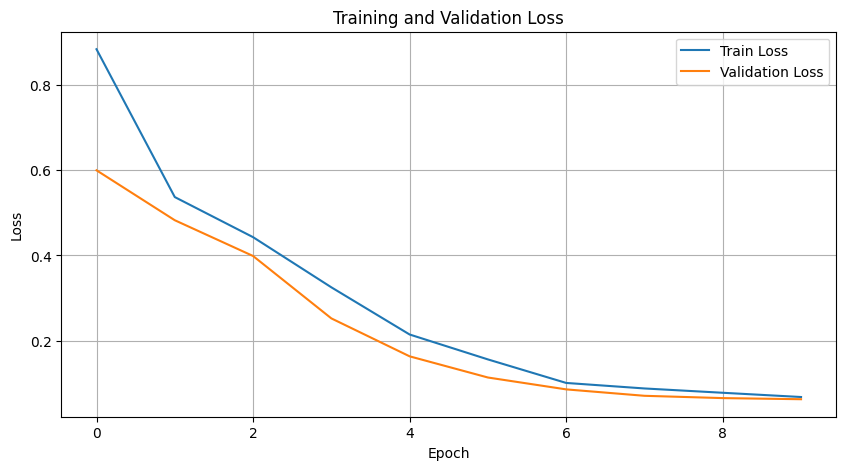

In [ ]:
# plot the loss
plt.figure(figsize=(10, 5))
plt.plot(loss_dict["train"], label="Train Loss")
plt.plot(loss_dict["val"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

To show that our model doesnt overfit, we will be testing it on both the training dataset and the validation dataset on which the model wasnt trained. We see that although there is some differences they are in fact minimal and thus we can conclude that the model does not overfit.


In [ ]:
with torch.no_grad():
    val_loss_sum = 0
    epoch_loss_sum = 0

    for x_val, y_val in val_loader:
        y_pred = model(x_val)
        #print("prediction: ",y_pred," Actual: ", y_val)
        loss = loss_fn(y_pred, y_val)
        val_loss_sum += loss.item()

    for x_val, y_val in train_loader:
        y_pred = model(x_val)
        #print("prediction: ",y_pred," Actual: ", y_val)
        loss = loss_fn(y_pred, y_val)
        epoch_loss_sum += loss.item()

avg_train_loss = epoch_loss_sum / len(train_loader)

avg_val_loss = val_loss_sum / len(val_loader)
print("Validation dataset loss: ", avg_val_loss, " Train dataset loss: ", avg_train_loss )

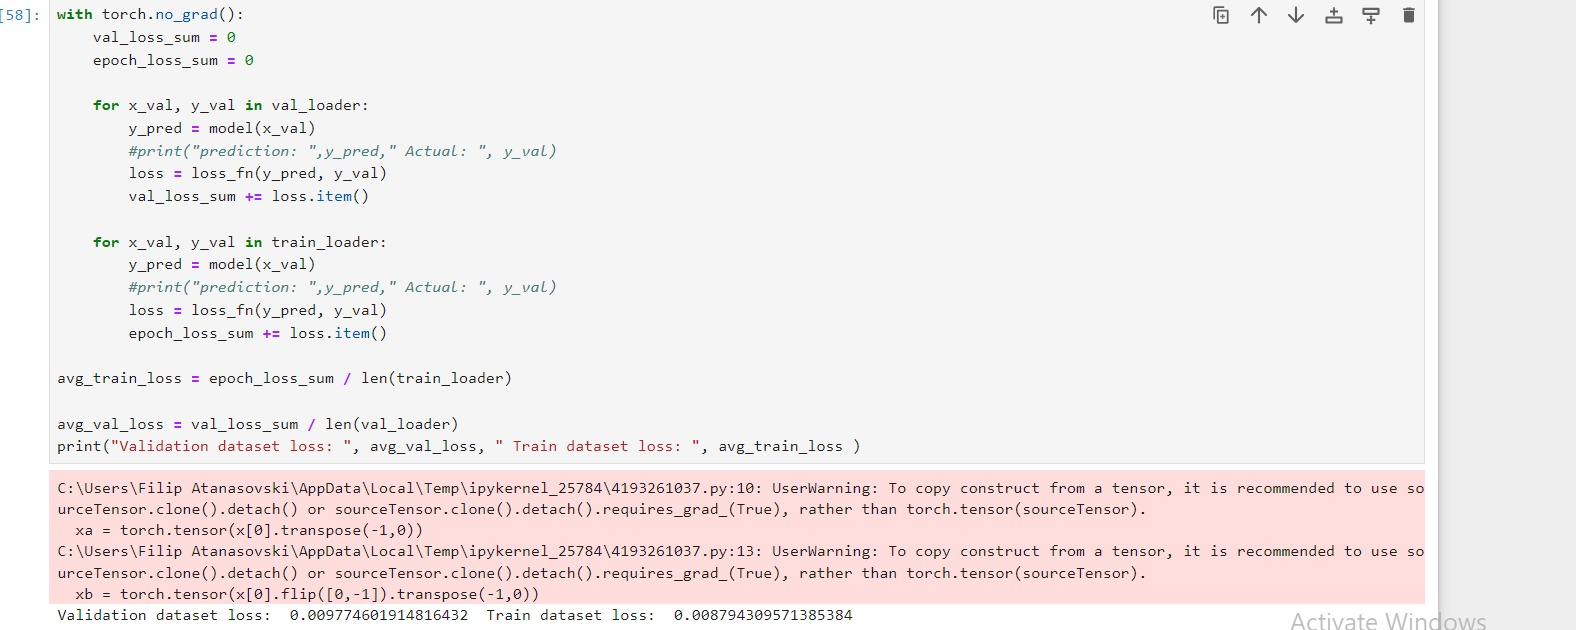

## Conclusion

In conclusion, the overall performace of the neural network was decent with a relatively low RMSPE value. Given that we train the neural network using GPU, it allows us to train neural networks with large number of neurons and epochs. To show that our model doesn't overfit on the training data, a plot of the train loss versus validation loss was plotted. However, the number of parameters used in the training was 151018 which was consider large and inefficient. In the future, a model with less parameters could be designed to reduce computational complexity and increase efficiency.

## AI/ChatGPT usage

Regarding AI/ChatGPT usage, AI tools were not utilized when designing our neural network. A few points and sentences on the explaination of the theories and concepts are quoted from ChatGPT but the whole theory part is written by ourselves.

## References

[1] Image sourced from https://www.quora.com/Where-is-the-symmetry-in-group-theory

[2] Corebetta, Alessandro. "Lecture 9 Machine Learning in Science." Machine Learning in Science, 2024.

[3] Corebetta, Alessandro. "Lecture 11 Machine Learning in Science." Machine Learning in Science, 2024

[4] Gallay, Charles. “Exploiting Symmetries (in Images) With Graph Neural Networks.” Exploiting Symmetries (in Images) With Graph Neural Networks,cgallay.github.io/GraphSymmetries.

[5] Raj, Bharath. “Data Augmentation | How to Use Deep Learning When You Have Limited Data — Part 2.” Medium, 12 Aug. 2019, medium.com/nanonets/how-to-use-deep-learning-when-you-have-limited-data-part-2-data-augmentation-c26971dc8ced.